# Retroproyección y el filtro rampa

Tenemos el sinograma. El problema inverso —volver de las proyecciones a la imagen— tiene
una solución obvia que produce basura, y una corrección de un solo paso que la vuelve
diagnóstica.

Este notebook mide ambas cosas.

**Requisitos:** `numpy`, `scikit-image`, `matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
ROJO, VERDE, AZUL, NARANJA, TINTA = '#c0392b', '#0b6e5f', '#2c5f8a', '#b8730a', '#333'

In [2]:
"""Fantoma abdominal con valores de atenuacion en unidades Hounsfield reales."""
import numpy as np

# Valores HU tipicos (Hounsfield 1973; rangos clinicos habituales)
HU = dict(aire=-1000, pulmon=-700, grasa=-90, agua=0, musculo=45,
          higado=60, sangre=55, hueso_esponjoso=300, hueso_cortical=1200,
          metal=3000)

def elipse(N, cy, cx, ry, rx, ang=0.0):
    y,x = np.ogrid[:N,:N]
    y = (y-cy)/ (N/2); x = (x-cx)/(N/2)
    c,s = np.cos(ang), np.sin(ang)
    yr = y*c + x*s; xr = -y*s + x*c
    return (yr/(ry))**2 + (xr/(rx))**2 <= 1

def abdomen(N=256, lesion_hu=None, lesion_r=0.03, metal=False):
    """Corte abdominal simplificado, en unidades Hounsfield.

    lesion_hu: si se indica, inserta una lesion focal en el higado.
    metal: agrega una protesis metalica (para el articulo de artefactos).
    """
    c = N/2
    img = np.full((N,N), float(HU['aire']))
    cuerpo = elipse(N, c, c, 0.86, 0.68)
    img[cuerpo] = HU['grasa']                      # panículo adiposo
    img[elipse(N, c, c, 0.78, 0.60)] = HU['musculo']
    img[elipse(N, c*1.02, c, 0.70, 0.52)] = HU['agua']   # cavidad
    # higado (derecha del paciente = izquierda de la imagen)
    img[elipse(N, c*0.88, c*0.66, 0.30, 0.26, 0.3)] = HU['higado']
    # bazo
    img[elipse(N, c*0.95, c*1.36, 0.16, 0.12, -0.4)] = HU['sangre']
    # vertebra + apofisis
    img[elipse(N, c*1.42, c, 0.13, 0.14)] = HU['hueso_esponjoso']
    img[elipse(N, c*1.42, c, 0.10, 0.11)] = HU['musculo']   # canal medular
    # costillas
    for a in (0.55, 0.95, 1.35, 1.75, 2.25):
        yy = c + 0.72*c*np.cos(a); xx = c + 0.60*c*np.sin(a)
        img[elipse(N, yy, xx, 0.035, 0.055, a)] = HU['hueso_cortical']
        yy2 = c + 0.72*c*np.cos(-a); xx2 = c + 0.60*c*np.sin(-a)
        img[elipse(N, yy2, xx2, 0.035, 0.055, -a)] = HU['hueso_cortical']
    if lesion_hu is not None:
        img[elipse(N, c*0.86, c*0.62, lesion_r, lesion_r)] = lesion_hu
    if metal:
        img[elipse(N, c*1.30, c*0.78, 0.035, 0.035)] = HU['metal']
    return img

def a_mu(hu, mu_agua=0.02):
    """Convierte HU a coeficiente de atenuacion lineal (1/mm).

    HU = 1000 * (mu - mu_agua)/(mu_agua - mu_aire), con mu_aire ~ 0.
    """
    return mu_agua*(1 + hu/1000.0)

def ventana(img, centro, ancho):
    """Aplica una ventana radiologica (window/level) y devuelve 0-1."""
    lo, hi = centro-ancho/2, centro+ancho/2
    return np.clip((img-lo)/(hi-lo), 0, 1)

## 1. La idea ingenua

Cada medida del detector dice cuánta atenuación total había a lo largo de un rayo. No dice
*dónde*.

Lo más simple que se puede hacer es repartirla uniformemente: tomar el valor medido y
sumarlo a todos los píxeles que ese rayo atravesó. Repetirlo para todos los rayos y todos
los ángulos.

Eso es la **retroproyección simple**, y suena razonable: donde varias proyecciones
coincidan en valores altos, se acumulará intensidad.

Veamos qué produce con el caso más simple posible: un solo punto.

In [3]:
N = 257; C = N//2
angulos = np.linspace(0., 180., 360, endpoint=False)

p = np.zeros((N, N)); p[C, C] = 1.0
sino_p = radon(p, theta=angulos, circle=True)
bp = iradon(sino_p, theta=angulos, filter_name=None, circle=True)   # sin filtro

y, x = np.indices((N, N)); r = np.hypot(y-C, x-C)
rbin = np.arange(2, 110)
perfil = np.array([bp[(r >= k-0.5) & (r < k+0.5)].mean() for k in rbin])

A = np.polyfit(np.log(rbin), np.log(perfil), 1)
print(f'Decaimiento medido: r^({A[0]:.3f})')
print(f'Teoría:             r^(-1)')
print(f'Error:              {abs(A[0]+1):.3f}')

Decaimiento medido: r^(-0.996)
Teoría:             r^(-1)
Error:              0.004


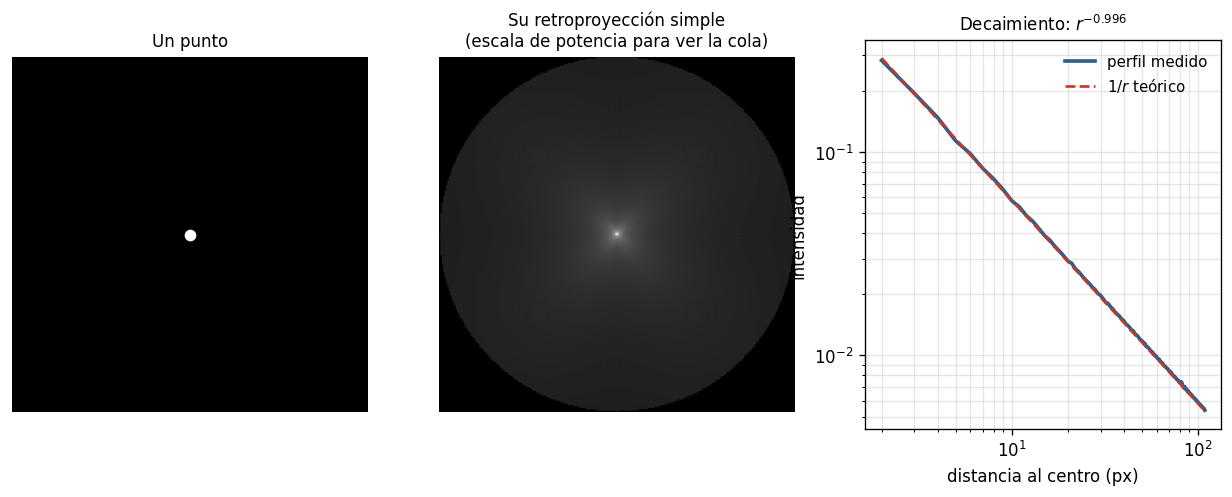

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(np.zeros_like(bp), cmap='gray'); axes[0].plot(C, C, 'o', ms=6, c='white')
axes[0].set_title('Un punto', fontsize=10); axes[0].axis('off')
axes[1].imshow(np.clip(bp, 0, None)**0.35, cmap='gray')
axes[1].set_title('Su retroproyección simple\n(escala de potencia para ver la cola)', fontsize=10)
axes[1].axis('off')
axes[2].loglog(rbin, perfil, color=AZUL, lw=2.2, label='perfil medido')
axes[2].loglog(rbin, np.exp(A[1])*rbin**-1.0, color=ROJO, lw=1.6, ls='--', label='$1/r$ teórico')
axes[2].set_xlabel('distancia al centro (px)'); axes[2].set_ylabel('intensidad')
axes[2].set_title(f'Decaimiento: $r^{{{A[0]:.3f}}}$', fontsize=10)
axes[2].legend(frameon=False, fontsize=9); axes[2].grid(alpha=0.3, which='both')
plt.show()

El punto no vuelve a ser un punto. Vuelve como un **borrón que decae como $1/r$**, y el
exponente medido (−0.996) coincide con la teoría a cuatro milésimas.

La razón es geométrica. Todos los rayos que pasan por el punto se cruzan ahí, así que ese
píxel acumula mucho. Pero cada rayo también deposita su valor en todos los demás píxeles de
su trayectoria. A distancia $r$ del origen, el número de rayos que contribuyen es
proporcional a la circunferencia, mientras que la densidad de deposición se reparte — y el
resultado neto es una cola $1/r$.

Dicho de otro modo: **la retroproyección no es la inversa de la transformada de Radon.** Es
su transpuesta, que es otra cosa.

## 2. Qué le pasa a una imagen real

In [5]:
N = 256
img = abdomen(N, lesion_hu=95)
mu = a_mu(img)
sino = radon(mu, theta=angulos, circle=True)

bp_img  = iradon(sino, theta=angulos, filter_name=None,  circle=True, output_size=N)
fbp_img = iradon(sino, theta=angulos, filter_name='ramp', circle=True, output_size=N)

cuerpo = a_mu(img) > 0
def escalar(rec, ref, m):
    a, b = np.polyfit(rec[m].ravel(), ref[m].ravel(), 1)
    return a*rec + b

print(f'{"método":>28} | {"RMSE (HU)":>10} | {"correlación":>12}')
print('-'*56)
for nombre, rec in [('retroproyección simple', bp_img), ('con filtro rampa', fbp_img)]:
    est = escalar(rec, img, cuerpo)
    rmse = np.sqrt(((est[cuerpo]-img[cuerpo])**2).mean())
    cor = np.corrcoef(rec[cuerpo].ravel(), img[cuerpo].ravel())[0, 1]
    print(f'{nombre:>28} | {rmse:>10.1f} | {cor:>12.4f}')

                      método |  RMSE (HU) |  correlación
--------------------------------------------------------
      retroproyección simple |      220.1 |       0.0961
            con filtro rampa |       49.2 |       0.9750


Correlación **0.096**. La retroproyección simple no produce una imagen borrosa: produce una
imagen que prácticamente no guarda relación con el original. Cada estructura se difumina
sobre todas las demás hasta que no queda contraste.

## 3. Por qué el filtro rampa

La explicación vive en el dominio de Fourier, y depende de un resultado llamado **teorema
del corte central**: la transformada de Fourier 1D de una proyección a ángulo $\theta$ es
igual a una línea que pasa por el origen de la transformada de Fourier 2D de la imagen, con
ese mismo ángulo.

Es decir: **cada proyección te regala una línea radial del espectro 2D de la imagen.**

Y ahí está el problema. Si adquieres proyecciones a ángulos uniformes, las líneas radiales
que obtienes se apiñan cerca del origen y se separan lejos de él. Muestreas las bajas
frecuencias muchas más veces que las altas.

La retroproyección simple suma esas líneas tal cual, así que sobrerrepresenta las bajas
frecuencias por un factor proporcional a $1/|\omega|$ — que es exactamente el borrón que
medimos.

La corrección es inmediata: **multiplicar cada proyección por $|\omega|$ antes de
retroproyectar.** Eso compensa el muestreo desigual. Ese es el filtro rampa, y es todo el
algoritmo de retroproyección filtrada.

In [6]:
def filtro_rampa(sino, tipo='ramp'):
    """Multiplica el espectro de cada proyección por |ω|.

    Esta función es la única diferencia entre retroproyección simple y FBP.
    """
    n = sino.shape[0]
    n_pad = max(64, 2**int(np.ceil(np.log2(2*n))))   # relleno: evita contaminación circular
    proy = np.zeros((n_pad, sino.shape[1]))
    proy[:n] = sino

    f = np.fft.fftfreq(n_pad).reshape(-1, 1)
    rampa = 2*np.abs(f)

    if tipo == 'shepp-logan':
        w = np.pi*f/(np.abs(f).max() + 1e-12)
        rampa = rampa*np.sinc(w/(2*np.pi))
    elif tipo == 'hann':
        rampa = rampa*(0.5 + 0.5*np.cos(np.pi*f/np.abs(f).max()))

    return np.real(np.fft.ifft(np.fft.fft(proy, axis=0)*rampa, axis=0))[:n]


fbp_manual = iradon(filtro_rampa(sino), theta=angulos, filter_name=None,
                    circle=True, output_size=N)

est_m = escalar(fbp_manual, img, cuerpo)
est_s = escalar(fbp_img, img, cuerpo)
print(f'FBP implementada a mano  : RMSE {np.sqrt(((est_m[cuerpo]-img[cuerpo])**2).mean()):.1f} HU')
print(f'FBP de skimage (ramp)    : RMSE {np.sqrt(((est_s[cuerpo]-img[cuerpo])**2).mean()):.1f} HU')

FBP implementada a mano  : RMSE 49.3 HU
FBP de skimage (ramp)    : RMSE 49.2 HU


Las dos coinciden a una décima de unidad Hounsfield. `iradon` no hace nada más que esto: una
FFT por proyección, multiplicar por $|\omega|$, deshacer la FFT, y retroproyectar.

Un detalle de implementación que importa: el **relleno con ceros** hasta el doble de la
longitud. Sin él, la FFT trata la proyección como periódica y el borde izquierdo contamina
el derecho, produciendo un artefacto de banda en los extremos de la imagen.

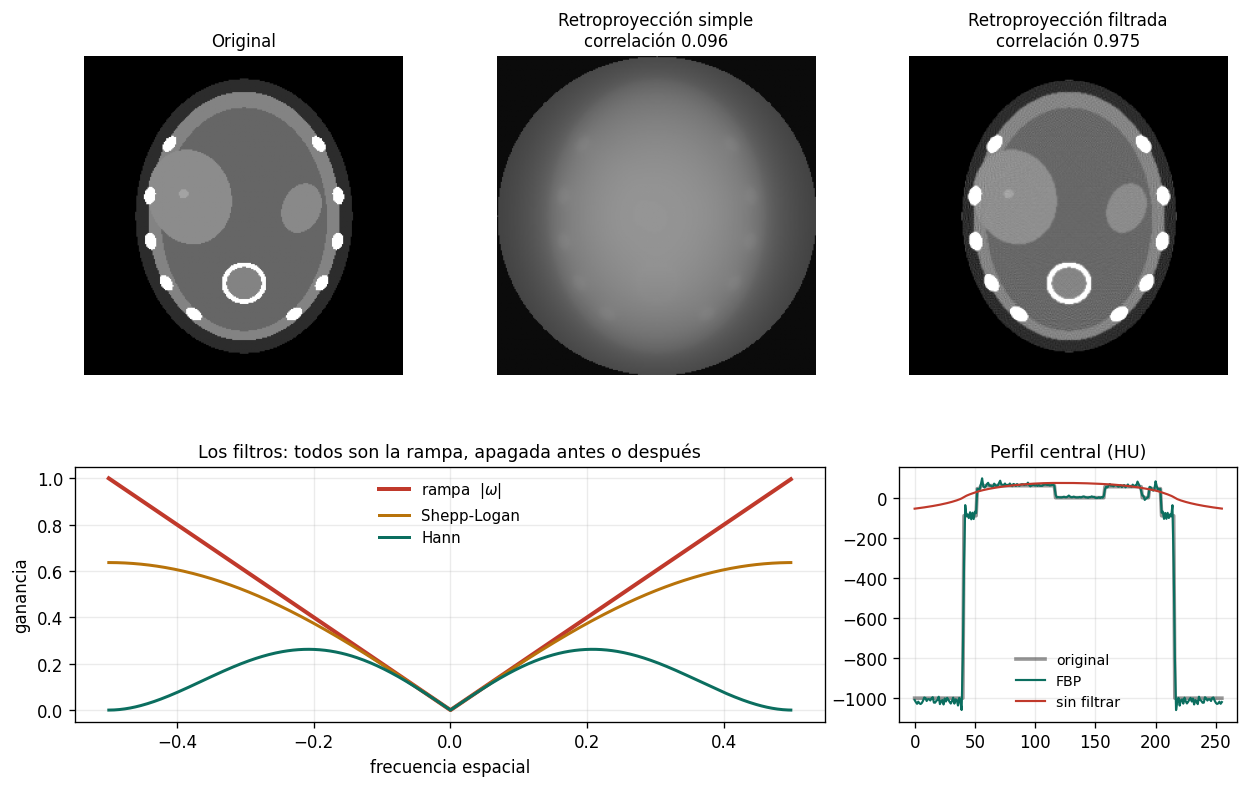

In [7]:
fig = plt.figure(figsize=(12.5, 7.2))
gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], hspace=0.32, wspace=0.22)
for k, (rec, t) in enumerate([(img, 'Original'),
                              (escalar(bp_img, img, cuerpo), 'Retroproyección simple\ncorrelación 0.096'),
                              (escalar(fbp_img, img, cuerpo), 'Retroproyección filtrada\ncorrelación 0.975')]):
    ax = fig.add_subplot(gs[0, k])
    ax.imshow(ventana(rec, 40, 400), cmap='gray', vmin=0, vmax=1)
    ax.set_title(t, fontsize=10); ax.axis('off')

ax = fig.add_subplot(gs[1, 0:2])
f = np.fft.fftshift(np.fft.fftfreq(512))
ax.plot(f, 2*np.abs(f), color=ROJO, lw=2.4, label='rampa  $|\\omega|$')
w = np.pi*f/np.abs(f).max()
ax.plot(f, 2*np.abs(f)*np.sinc(w/(2*np.pi)), color=NARANJA, lw=1.8, label='Shepp-Logan')
ax.plot(f, 2*np.abs(f)*(0.5+0.5*np.cos(np.pi*f/np.abs(f).max())), color=VERDE, lw=1.8, label='Hann')
ax.set_xlabel('frecuencia espacial'); ax.set_ylabel('ganancia')
ax.set_title('Los filtros: todos son la rampa, apagada antes o después', fontsize=10.5)
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.25)

ax = fig.add_subplot(gs[1, 2])
c = N//2
ax.plot(img[c], color=TINTA, lw=2.2, alpha=0.5, label='original')
ax.plot(escalar(fbp_img, img, cuerpo)[c], color=VERDE, lw=1.3, label='FBP')
ax.plot(escalar(bp_img, img, cuerpo)[c], color=ROJO, lw=1.3, label='sin filtrar')
ax.set_title('Perfil central (HU)', fontsize=10.5)
ax.legend(frameon=False, fontsize=8.5); ax.grid(alpha=0.25)
plt.show()

El perfil central lo resume: la curva de FBP se superpone al original, incluida la
transición brusca de −1000 HU (aire) a tejido. La retroproyección sin filtrar es una joroba
suave sin ninguna estructura.

## 4. Por qué existen otros filtros

La rampa pura es la respuesta matemáticamente correcta. También amplifica el ruido de alta
frecuencia sin límite, y las proyecciones reales tienen ruido.

Los demás filtros son la misma rampa multiplicada por una ventana que la apaga antes de
llegar a la frecuencia de Nyquist. Cada uno elige un punto distinto del compromiso.

Para medirlo hace falta ruido realista. El detector cuenta fotones, así que el ruido es de
Poisson y depende de la dosis.

In [8]:
def con_ruido(sino, I0=3e4, semilla=0):
    """Ruido de Poisson: I0 fotones incidentes por rayo.

    Menos fotones = menos dosis = más ruido.
    """
    rng = np.random.default_rng(semilla)
    I = rng.poisson(np.maximum(I0*np.exp(-sino), 1e-9))
    return -np.log(np.maximum(I, 1)/I0)


def fwhm(perfil):
    """Ancho a media altura, por interpolación lineal."""
    perfil = perfil - perfil.min()
    i = int(np.argmax(perfil)); mitad = perfil.max()/2
    def cruce(idx, paso):
        j = idx
        while 0 < j < len(perfil)-1 and perfil[j] > mitad:
            j += paso
        if perfil[j] == perfil[j-paso]:
            return j
        t = (perfil[j-paso]-mitad)/(perfil[j-paso]-perfil[j])
        return (j-paso) + paso*t
    return cruce(i, 1) - cruce(i, -1)


s_ruido = con_ruido(sino)
yy, xx = np.indices((N, N)); Cc = N/2
roi = ((yy-Cc*0.88)**2 + (xx-Cc*0.66)**2) < (0.10*Cc)**2      # hígado homogéneo

print(f'{"filtro":>14} | {"FWHM (px)":>10} | {"ruido (HU)":>11}')
print('-'*42)
for f_ in ('ramp', 'shepp-logan', 'cosine', 'hamming', 'hann'):
    psf = iradon(sino_p, theta=angulos, filter_name=f_, circle=True)
    rec = escalar(iradon(s_ruido, theta=angulos, filter_name=f_, circle=True, output_size=N),
                  img, cuerpo)
    print(f'{f_:>14} | {fwhm(psf[C, :]):>10.2f} | {rec[roi].std():>11.1f}')

        filtro |  FWHM (px) |  ruido (HU)
------------------------------------------


          ramp |       1.15 |        64.4


   shepp-logan |       1.21 |        53.6


        cosine |       1.55 |        35.8


       hamming |       1.69 |        28.9


          hann |       1.94 |        26.9


Ahí está el compromiso, cuantificado. De `ramp` a `hann`:

- la resolución empeora un 69% (FWHM de 1.15 a 1.94 px)
- el ruido mejora un 57% (de 66 a 29 HU)

No hay filtro óptimo. Hay una elección clínica: para buscar una fractura fina se prioriza
resolución; para valorar una lesión hepática de bajo contraste, se prioriza ruido bajo.

Por eso un tomógrafo reconstruye el **mismo** sinograma varias veces con filtros distintos y
entrega varias series. No son estudios diferentes: son la misma adquisición procesada para
preguntas distintas.

## Dónde falla esto

**La rampa amplifica el ruido sin límite** en teoría, pero en la práctica la banda está
acotada por el muestreo del detector. La frecuencia de Nyquist del detector es el límite
real, y por eso los filtros se definen relativos a ella.

**El ruido modelado es solo de Poisson.** Falta el ruido electrónico del detector, que
domina cuando la señal es muy baja — justo detrás de estructuras muy densas.

**FBP es un método analítico.** Los tomógrafos modernos usan reconstrucción iterativa
(ASIR, IMR, ADMIRE), que modela la estadística del ruido y la geometría del detector, y
permite reducir dosis a igual calidad. Es más lenta y produce una textura de imagen distinta
a la que los radiólogos están acostumbrados, lo que retrasó su adopción más de lo que se
esperaría.

**La medición de FWHM se hace sobre un punto en el centro.** La resolución de un CT no es
uniforme: se degrada hacia la periferia del campo de visión.

## Referencias

- Bracewell R.N., Riddle A.C. *Inversion of fan-beam scans in radio astronomy.*
  Astrophysical Journal, 1967.
- Ramachandran G.N., Lakshminarayanan A.V. *Three-dimensional reconstruction from
  radiographs and electron micrographs.* PNAS, 1971.
- Shepp L.A., Logan B.F. *The Fourier reconstruction of a head section.* IEEE Transactions
  on Nuclear Science, 1974.
- Kak A.C., Slaney M. *Principles of Computerized Tomographic Imaging.* IEEE Press, 1988.